In [48]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(40,)


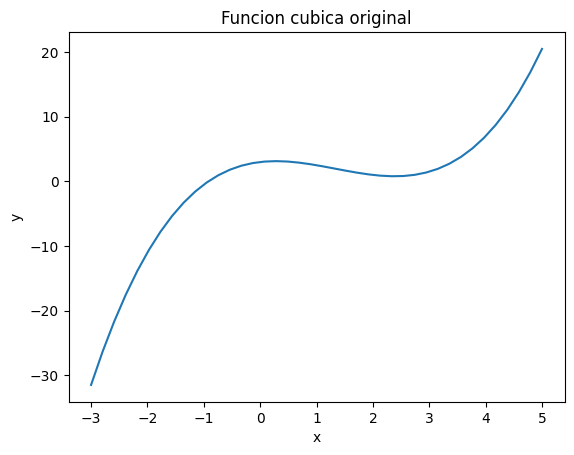

In [49]:
def funcionPrueba(x):
    return 0.5*x**3 - 2*x**2 + x + 3

x = np.linspace(-3,5,40)
y = funcionPrueba(x)

print(x.shape)

plt.figure()
plt.plot(x,y)
plt.title("Funcion cubica original")
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [50]:
x_train = x.reshape(-1,1)
y_train = y.reshape(-1,1)

print(f"El shape de x_train es :{x_train.shape}")
print(f"El shape de y_train es :{y_train.shape}")

El shape de x_train es :(40, 1)
El shape de y_train es :(40, 1)


In [51]:
learning_rate = 0.001

modelo = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

c:\Users\franc\Documents\pythonEnv\dev\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [52]:
optimizador = tf.keras.optimizers.Adam(learning_rate=learning_rate)

modelo.compile(
    optimizer=optimizador,
    loss='mse'
)

In [53]:
modelo.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 16)             │            32 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609 (2.38 KB)

 Trainable params: 609 (2.38 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
historia = modelo.fit(
    x_train, y_train,
    epochs = 800,
    # batch_size = x_train.shape[0],
    batch_size = 16,
    verbose=1
)

Epoch 1/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 103.5322 
Epoch 2/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 102.5260
Epoch 3/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 101.6989
Epoch 4/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 100.7710
Epoch 5/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 99.8278 
Epoch 6/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 98.8706
Epoch 7/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 97.9555
Epoch 8/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 97.2658 
Epoch 9/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 96.2853  
Epoch 10/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 95.3784
Epoch 11/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 94.5679 
Epoch 12/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 93.6225
Epoch 13/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 92.7784  
Epoch 14/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 91.8569 
Epoch 15/800
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 90.9

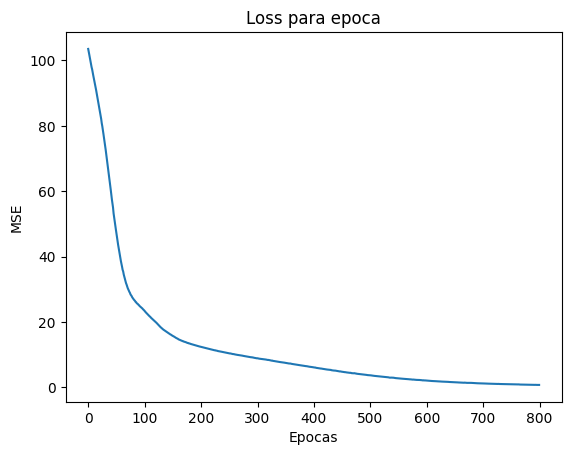

In [55]:
# PARA CONJUNTO COMPLETO : LOSS 21.8310 - para 1000 iter
# PARA CONJUNTO COMPLETO : LOSS 11.9306 - para 2000 iter

# PARA CONJUNTO COMPLETO : LOSS 15.0377 - para 1000 iter
# PARA CONJUNTO COMPLETO : LOSS 3.3992 - para 1000 iter

plt.figure()
plt.plot(historia.history['loss'])
plt.title('Loss para epoca')
plt.xlabel('Epocas')
plt.ylabel('MSE')
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


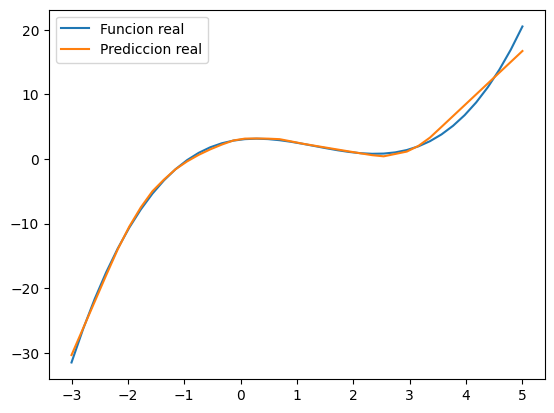

In [56]:
y_pred = modelo.predict(x_train)

plt.figure()
plt.plot(x,y, label='Funcion real')
plt.plot(x,y_pred, label='Prediccion real')
plt.legend()
plt.show()